# Day 2
## pandas

In [5]:
import pandas as pd 
import numpy as np
print(" All packages imported successfully")
print("pandas version:",pd.__version__)
print("Numpy version:", np.__version__)

 All packages imported successfully
pandas version: 3.0.3
Numpy version: 2.4.6


In [6]:
# Import the tools we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import pickle

print("="*50)
print("STUDENT PERFORMANCE PREDICTION")
print("="*50)

# Load the data we created in Day 1
df = pd.read_csv('student_perfomance.csv')
print("\n✅ Loaded student data from Day 1")

print(f"\n📊 We have data for {len(df)} students")
print(f"📋 Columns: {list(df.columns)}")
print("\nFirst 5 students:")
print(df.head())

STUDENT PERFORMANCE PREDICTION

✅ Loaded student data from Day 1

📊 We have data for 500 students
📋 Columns: ['student_id', 'hours_studied', 'previous_score', 'attendance', 'sleep_hours', 'extracurricular', 'parent_education', 'internet_access', 'final_score', 'extracurricular_encoded', 'parent_education_encoded', 'internet_access_encoded']

First 5 students:
   student_id  hours_studied  previous_score  attendance  sleep_hours  \
0           1              7              97          72          4.2   
1           2              4              97          64          5.3   
2           3             13              61          86          5.4   
3           4             11              88          70          8.0   
4           5              8              91          63          4.1   

  extracurricular parent_education internet_access  final_score  \
0             Yes           Master              No        86.71   
1              No         Bachelor             Yes        87.98  

In [7]:
# load iris data
iris_df = pd.read_csv('Data/iris.csv')
print("\n✅ Loaded Iris dataset")
print(f"\n📊 We have data for {len(iris_df)} iris samples")

# Explore the iris dataset
print("\nFirst 5 iris samples:")
print(iris_df.head())

print("\n📋 Iris Columns:", list(iris_df.columns))

print("\n📊 Statistics of Iris Dataset:")
print(iris_df.describe())


✅ Loaded Iris dataset

📊 We have data for 150 iris samples

First 5 iris samples:
  sepal_length\tsepal_width\tpetal_length\tpetal_width\tspecies
0                         5.1\t3.5\t1.4\t0.2\tsetosa           
1                           4.9\t3\t1.4\t0.2\tsetosa           
2                         4.7\t3.2\t1.3\t0.2\tsetosa           
3                         4.6\t3.1\t1.5\t0.2\tsetosa           
4                           5\t3.6\t1.4\t0.2\tsetosa           

📋 Iris Columns: ['sepal_length\tsepal_width\tpetal_length\tpetal_width\tspecies']

📊 Statistics of Iris Dataset:
       sepal_length\tsepal_width\tpetal_length\tpetal_width\tspecies
count                                                 150           
unique                                                147           
top                            4.9\t3.1\t1.5\t0.1\tsetosa           
freq                                                    3           


Sample of students:
--------------------------------------------------
   hours_studied  final_score
0              7        86.71
1              4        87.98
2             13       100.00
3             11       100.00
4              8        98.38
5             13       100.00
6              5        69.64
7              7        84.54
8             10       100.00
9              3        87.92

📊 Average scores by study hours:
--------------------------------------------------
hours_studied
1     75.7
2     74.4
3     77.2
4     83.3
5     85.7
6     84.5
7     88.4
8     91.8
9     93.7
10    94.9
11    97.4
12    96.8
13    96.6
14    97.7
Name: final_score, dtype: float64


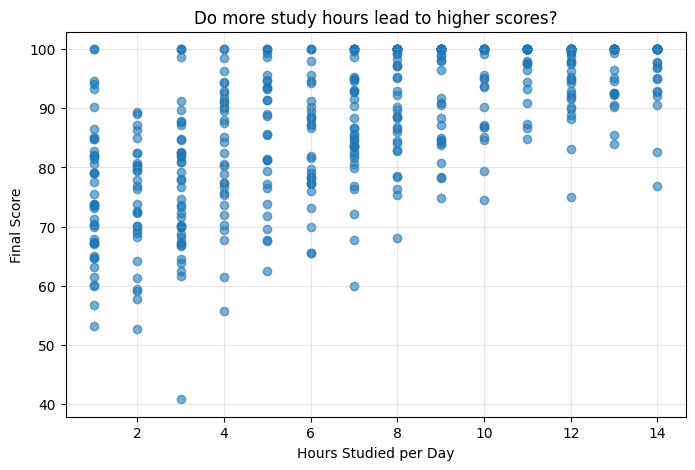


💡 What we see:
   - Students who study more tend to score higher
   - But it's not perfect (other factors matter too)
   - This is where our ML model will help!


In [8]:
# Look at a few students
print("Sample of students:")
print("-"*50)
print(df[['hours_studied', 'final_score']].head(10))

# Calculate average score for different study hours
print("\n📊 Average scores by study hours:")
print("-"*50)

# Group by hours studied and calculate average
avg_by_hours = df.groupby('hours_studied')['final_score'].mean().round(1)
print(avg_by_hours)

# Make a simple plot
plt.figure(figsize=(8, 5))
plt.scatter(df['hours_studied'], df['final_score'], alpha=0.6)
plt.xlabel('Hours Studied per Day')
plt.ylabel('Final Score')
plt.title('Do more study hours lead to higher scores?')
plt.grid(True, alpha=0.3)
plt.show()

print("\n💡 What we see:")
print("   - Students who study more tend to score higher")
print("   - But it's not perfect (other factors matter too)")
print("   - This is where our ML model will help!")

In [9]:
# Select our feature (what we know) and target (what we want to predict)
feature = ['hours_studied']  # We'll use study hours to predict
target = 'final_score'        # What we want to predict

X = df[feature]  # Features (input)
y = df[target]   # Target (output)

print("✅ Features (what we know):")
print(X.head())
print("\n✅ Target (what we want to predict):")
print(y.head())

print(f"\n📊 We have {len(X)} students")
print(f"   Each student has {len(feature)} feature: study hours")

✅ Features (what we know):
   hours_studied
0              7
1              4
2             13
3             11
4              8

✅ Target (what we want to predict):
0     86.71
1     87.98
2    100.00
3    100.00
4     98.38
Name: final_score, dtype: float64

📊 We have 500 students
   Each student has 1 feature: study hours


In [10]:
# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"📊 Data Split:")
print(f"   Training set: {len(X_train)} students (80%)")
print(f"   Testing set: {len(X_test)} students (20%)")

print(f"\n📚 Training students (first 5):")
print(X_train.head())

print(f"\n🎯 Their scores (first 5):")
print(y_train.head())

📊 Data Split:
   Training set: 400 students (80%)
   Testing set: 100 students (20%)

📚 Training students (first 5):
     hours_studied
249             12
433              3
19               6
322             14
332              2

🎯 Their scores (first 5):
249    100.00
433    100.00
19      94.60
322    100.00
332     68.94
Name: final_score, dtype: float64


In [11]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("✅ Model training complete!")
print("\n📐 The model found this formula:")

# Get the numbers the model learned
intercept = model.intercept_
coefficient = model.coef_[0]

print(f"   Predicted Score = {coefficient:.2f} × (Study Hours) + {intercept:.2f}")
print(f"\n💡 This means:")
print(f"   - Base score (0 study hours): {intercept:.1f} points")
print(f"   - Each study hour adds: {coefficient:.2f} points")
print(f"   - If a student studies 5 hours: {5 * coefficient + intercept:.1f} points")
print(f"   - If a student studies 10 hours: {10 * coefficient + intercept:.1f} points")

✅ Model training complete!

📐 The model found this formula:
   Predicted Score = 1.96 × (Study Hours) + 73.51

💡 This means:
   - Base score (0 study hours): 73.5 points
   - Each study hour adds: 1.96 points
   - If a student studies 5 hours: 83.3 points
   - If a student studies 10 hours: 93.1 points


In [12]:
# Make predictions on test data
predictions = model.predict(X_test)

# Create a simple table to compare
results = pd.DataFrame({
    'Actual Score': y_test.values,
    'Predicted Score': predictions.round(1),
    'Difference': abs(y_test.values - predictions).round(1)
})

print("📊 Comparing Predictions vs Actual:")
print("-"*50)
print(results.head(10))
print("-"*50)

# Calculate average error
avg_error = results['Difference'].mean()
print(f"\n📊 Average prediction error: {avg_error:.1f} points")
print(f"   (This means on average, we're off by {avg_error:.1f} points)")

📊 Comparing Predictions vs Actual:
--------------------------------------------------
   Actual Score  Predicted Score  Difference
0        100.00            100.9         0.9
1         83.96             99.0        15.0
2         92.90             81.3        11.6
3        100.00             89.2        10.8
4         97.24             89.2         8.1
5         97.03            100.9         3.9
6         67.85             75.5         7.6
7         59.91             75.5        15.6
8         61.43             81.3        19.9
9         84.13             89.2         5.1
--------------------------------------------------

📊 Average prediction error: 7.4 points
   (This means on average, we're off by 7.4 points)


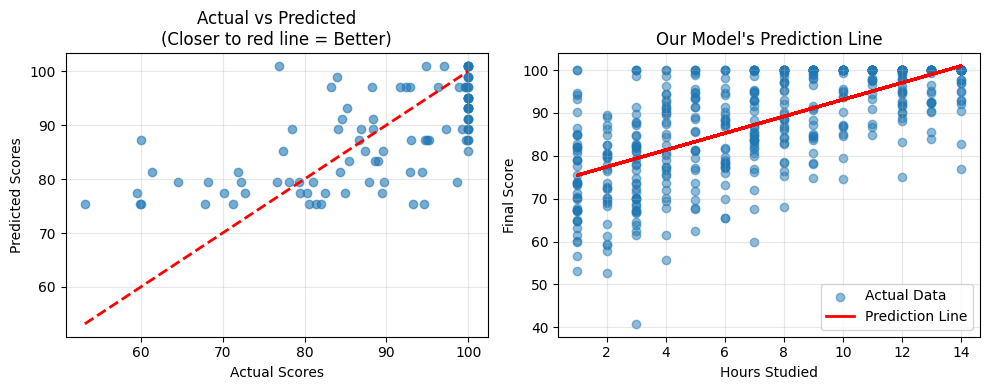

💡 What these graphs show:
   Left: Points close to red line = good predictions
   Right: The red line is our model - it predicts scores based on study hours


In [13]:
# Create a plot to see how well our model predicts
plt.figure(figsize=(10, 4))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test, predictions, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.title('Actual vs Predicted\n(Closer to red line = Better)')
plt.grid(True, alpha=0.3)

# Plot 2: The regression line
plt.subplot(1, 2, 2)
plt.scatter(X, y, alpha=0.5, label='Actual Data')
plt.plot(X_test, predictions, 'r-', linewidth=2, label='Prediction Line')
plt.xlabel('Hours Studied')
plt.ylabel('Final Score')
plt.title('Our Model\'s Prediction Line')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 What these graphs show:")
print("   Left: Points close to red line = good predictions")
print("   Right: The red line is our model - it predicts scores based on study hours")

In [14]:
# Calculate simple metrics to understand model quality

# 1. Mean Absolute Error (MAE) - Average error in points
mae = mean_absolute_error(y_test, predictions)

# 2. R-squared - How much variance we explain (0 to 1, higher is better)
r2 = r2_score(y_test, predictions)

print("📊 Model Performance Report:")
print("="*40)
print(f"✓ Mean Absolute Error (MAE): {mae:.1f} points")
print(f"  → On average, our prediction is off by {mae:.1f} points")

print(f"\n✓ R-squared (R²): {r2:.3f}")
print(f"  → Our model explains {r2*100:.1f}% of why students get different scores")

# Simple interpretation
if r2 > 0.7:
    print("\n🎉 Great! The model is working very well!")
elif r2 > 0.5:
    print("\n👍 Good! The model captures the main pattern")
else:
    print("\n📝 The model is simple but gives us a basic understanding")

📊 Model Performance Report:
✓ Mean Absolute Error (MAE): 7.4 points
  → On average, our prediction is off by 7.4 points

✓ R-squared (R²): 0.411
  → Our model explains 41.1% of why students get different scores

📝 The model is simple but gives us a basic understanding


In [15]:
# Use multiple features to improve the model

# Instead of just 'hours_studied', use both 'hours_studied' and 'attendance'
# Let's see if this improves predictions

# Select multiple features
features_multiple = ['hours_studied', 'attendance']
X_multi = df[features_multiple]
y_multi = df['final_score']

# Split data
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

# Train new model
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

# Make predictions
predictions_multi = model_multi.predict(X_test_m)

# Calculate R²
r2_multi = r2_score(y_test_m, predictions_multi)

print(f"R² with only study hours: {r2:.3f}")
print(f"R² with study hours + attendance: {r2_multi:.3f}")
print(f"\n📈 Improvement: {(r2_multi - r2)*100:.1f}% better!")

R² with only study hours: 0.411
R² with study hours + attendance: 0.513

📈 Improvement: 10.2% better!


In [16]:
# Include all the features we have to see if it improves further
# 📋 Columns: ['student_id', 'hours_studied', 'previous_score', 'attendance', 'sleep_hours', 'extracurricular', 'parent_education', 'internet_access', 'final_score', 'extracurricular_encoded', 'parent_education_encoded', 'internet_access_encoded']

features_all = [
    'hours_studied',
    'previous_score',
    'attendance',
    'sleep_hours','extracurricular_encoded', 'parent_education_encoded', 'internet_access_encoded']
X_all = df[features_all]
y_all = df['final_score']

# Split data
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(X_all, y_all, test_size=0.2, random_state=42)
# Train new model
model_all = LinearRegression()
model_all.fit(X_train_all, y_train_all)

# Make predictions
predictions_all = model_all.predict(X_test_all)

# Calculate R²
r2_all = r2_score(y_test_all, predictions_all)

print(f"R² with only study hours: {r2:.3f}")
print(f"R² with study hours + attendance: {r2_multi:.3f}")
print(f"R² with all features: {r2_all:.3f}")

R² with only study hours: 0.411
R² with study hours + attendance: 0.513
R² with all features: 0.812


In [17]:
# Export the model so we can use it in our Flask app later
with open('simple_student_model_all.pkl', 'wb') as file:
    pickle.dump(model_all, file)

print("\n✅ Model exported as 'simple_student_model_all.pkl' for use in Flask app")


✅ Model exported as 'simple_student_model_all.pkl' for use in Flask app


# Day 3
## code


In [18]:
# Exercise 2: Find hours needed for target score
target_score = 75

# Formula: Score = coefficient × hours + intercept
# So: hours = (Score - intercept) / coefficient

# YOUR CODE HERE
hours_needed = 0  # Calculate this

print(f"To score {target_score} points, study: {hours_needed:.1f} hours/day")

# SOLUTION
hours_needed = (target_score - intercept) / coefficient
print(f"To score {target_score} points, study: {hours_needed:.1f} hours/day")

To score 75 points, study: 0.0 hours/day
To score 75 points, study: 0.8 hours/day


In [19]:
# view Data  
print("First 5 rows")
print(df.head(5))
# view list rows 
print("\n last 2 rows:")
print(df.tail(7))
# 
print("\nStatistical Summary:")
print(df.describe())
print("\n Missing Values :")
print(df.isnull().sum())
print("\n Check for Nam Values:")
print(df.isna().sum)
print("\n Dublicate Rows:")
print(df.duplicated().sum())

First 5 rows
   student_id  hours_studied  previous_score  attendance  sleep_hours  \
0           1              7              97          72          4.2   
1           2              4              97          64          5.3   
2           3             13              61          86          5.4   
3           4             11              88          70          8.0   
4           5              8              91          63          4.1   

  extracurricular parent_education internet_access  final_score  \
0             Yes           Master              No        86.71   
1              No         Bachelor             Yes        87.98   
2             Yes           Master             Yes       100.00   
3             Yes           Master             Yes       100.00   
4              No      High School             Yes        98.38   

   extracurricular_encoded  parent_education_encoded  internet_access_encoded  
0                        1                         2             

In [20]:
# # print("Selecting  String")
# # print(df["student_name"])

# # print("\n Selecting  multiple columns;")
# # print("")
# # df[]

# def get_grade(score):
#     if score >= 90:
#         return "A"
#     elif score >= 80:
#         return "B"
#     elif score >= 70:
#         return "C"
#     elif score >= 60:
#         return "D"
#     else:
#         return "F"
# df['grade'] = df['previous_score'].apply(calculate_grage)
# print("DataFrame with new columns:")

# df['exe']

In [22]:
data = {
    'student_name':['Alice','Bob','Charlie','Diman','Eve','Alice'],
    'Hours_student':[5,8,3,10,6,5],
    'previous_score':[65,85,55,92,54,65],
    'attendance':[80,90,70,85,95,80],
    'sleep_hour':[7.8,6.8,6.9,4.7,9.8,7.8],
    'extracurricular':['yes','No','yes','No','yes','yes'],
    'parent_education':['Bachelor','Master','High score','Bachelor','High school','Bachelor']
    
}

df = pd.DataFrame(data)
print("Student performance DataForm;")
print(df)

# Basic dataForm Information
print("\nDataform Shape:",df.shape[0],"rows,",df.shape[1],"columns")
print("Column names:",df.columns.to_list())
print("Data types:\n",df.dtypes)
# print(df.info())

Student performance DataForm;
  student_name  Hours_student  previous_score  attendance  sleep_hour  \
0        Alice              5              65          80         7.8   
1          Bob              8              85          90         6.8   
2      Charlie              3              55          70         6.9   
3        Diman             10              92          85         4.7   
4          Eve              6              54          95         9.8   
5        Alice              5              65          80         7.8   

  extracurricular parent_education  
0             yes         Bachelor  
1              No           Master  
2             yes       High score  
3              No         Bachelor  
4             yes      High school  
5             yes         Bachelor  

Dataform Shape: 6 rows, 7 columns
Column names: ['student_name', 'Hours_student', 'previous_score', 'attendance', 'sleep_hour', 'extracurricular', 'parent_education']
Data types:
 student_name      

In [23]:
n_Student = 500
dataSet ={
    'Student_id':range(1,n_Student+1),
    'hours_Studied':np.random.randint(1,15,n_Student),
    'previous_score':np.random.randint(40,100,n_Student),
    'attendance':np.random.randint(50,100,n_Student),
    'sellp_houes':np.random.uniform(4,10,n_Student).round(1),
    'extracurricular':np.random.choice(['yes','no'],n_Student,p=[0.4,0.6]),
    'parent_education':np.random.choice(['High Schor,'Bachelor])
}

df_Student = pd.DataFrame(dataSet)

df_Students['final_score']=(
    df_Student['hours_s']
)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (164830134.py, line 9)

NameError: name 'df_students' is not defined

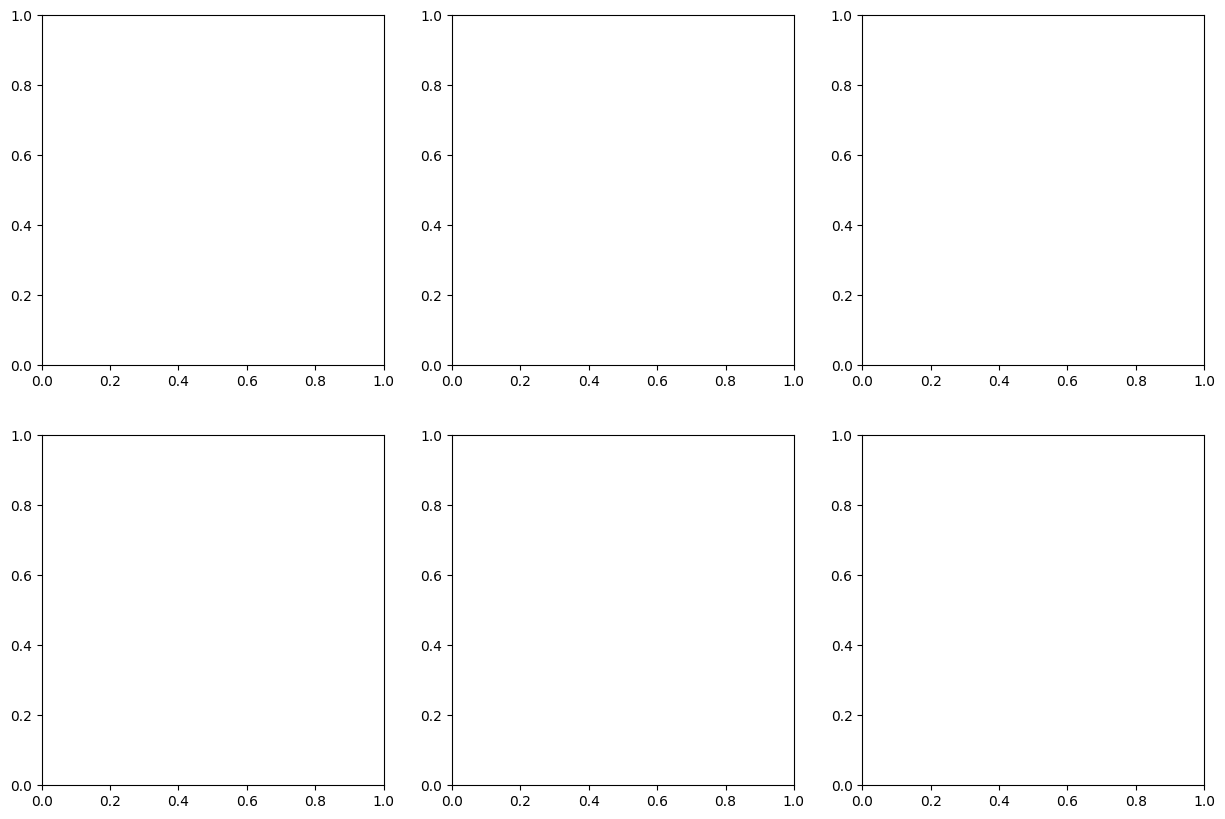

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Create visualizations to understand the data
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Distribution of final scores
axes[0, 0].hist(df_students['final_score'],bins=30,edgecolor='black',alpha=0.7)
axes[0, 0].set_title('Distribution of Final Scores', fontsize=12)
axes[0, 0].set_xlabel('Final Score')
axes[0, 0].set_ylabel('Number of Students')

# 2. Study hours vs Final Score
axes[0, 1].scatter(df_students['hours_studied'], df_students['final_score'], alpha=0.5)
axes[0, 1].set_title('Study Hours vs Final Score', fontsize=12)
axes[0, 1].set_xlabel('Hours Studied')
axes[0, 1].set_ylabel('Final Score')

# 3. Attendance vs Final Score
axes[0, 2].scatter(df_students['attendance'], df_students['final_score'], alpha=0.5, color='green')
axes[0, 2].set_title('Attendance vs Final Score', fontsize=12)
axes[0, 2].set_xlabel('Attendance (%)')
axes[0, 2].set_ylabel('Final Score')

# 4. Previous Score vs Final Score
axes[1, 0].scatter(df_students['previous_score'], df_students['final_score'], alpha=0.5, color='red')
axes[1, 0].set_title('Previous Score vs Final Score', fontsize=12)
axes[1, 0].set_xlabel('Previous Score')
axes[1, 0].set_ylabel('Final Score')

# 5. Box plot - Extracurricular vs Final Score
df_students.boxplot(column='final_score', by='extracurricular', ax=axes[1, 1])
axes[1, 1].set_title('Extracurricular Activities vs Final Score', fontsize=12)
axes[1, 1].set_xlabel('Extracurricular')
axes[1, 1].set_ylabel('Final Score')

# 6. Parent Education vs Final Score
education_order = ['High School', 'Bachelor', 'Master', 'PhD']
sns.boxplot(x='parent_education', y='final_score', data=df_students, order=education_order, ax=axes[1, 2])
axes[1, 2].set_title('Parent Education vs Final Score', fontsize=12)
axes[1, 2].set_xlabel('Parent Education')
axes[1, 2].set_ylabel('Final Score')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.suptitle('Student Performance Data Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Key Observations from Plots:")
print("1. Final scores roughly follow a normal distribution")
print("2. More study hours generally lead to higher scores")
print("3. Better attendance correlates with better performance")
print("4. Students with extracurricular activities tend to score higher")
print("5. Higher parent education level correlates with better scores")

In [ ]:
axes[1, 2].tick_params(axis='x', rotation=45)

plt.suptitle('Student Performance Data Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Key Observations from Plots:")
print("1. Final scores roughly follow a normal distribution")
print("2. More study hours generally lead to higher scores")
print("3. Better attendance correlates with better performance")
print("4. Students with extracurricular activities tend to score higher")
print("5. Higher parent education level correlates with better scores")
# Import the tools we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import pickle

print("="*50)
print("STUDENT PERFORMANCE PREDICTION")
print("="*50)

# Load the data we created in Day 1
try:
    df = pd.read_csv('student_performance.csv')
    print("\n✅ Loaded student data from Day 1")
except:
    # If Day 1 data doesn't exist, create simple data
    print("\n📝 Creating sample student data...")
    np.random.seed(42)
    
    # Create 100 students with random study hours
    df = pd.DataFrame({
        'hours_studied': np.random.randint(1, 12, 100),
        'previous_score': np.random.randint(50, 95, 100),
        'attendance': np.random.randint(60, 100, 100),
        'final_score': 0  # Will calculate below
    })
    
    # Calculate final score (more study hours = higher score)
    df['final_score'] = (df['hours_studied'] * 3.5 + df['previous_score'] * 0.4 + df['attendance'] * 0.2 + np.random.normal(0, 5, 100))
    df['final_score'] = df['final_score'].clip(40, 100).round(1)

print(f"\n📊 We have data for {len(df)} students")
print(f"📋 Columns: {list(df.columns)}")
print("\nFirst 5 students:")
print(df.head())

<Figure size 640x480 with 0 Axes>


📊 Key Observations from Plots:
1. Final scores roughly follow a normal distribution
2. More study hours generally lead to higher scores
3. Better attendance correlates with better performance
4. Students with extracurricular activities tend to score higher
5. Higher parent education level correlates with better scores
STUDENT PERFORMANCE PREDICTION

📝 Creating sample student data...

📊 We have data for 100 students
📋 Columns: ['hours_studied', 'previous_score', 'attendance', 'final_score']

First 5 students:
   hours_studied  previous_score  attendance  final_score
0              7              91          91         83.5
1              4              88          92         66.4
2             11              90          60         92.5
3              8              77          78         77.1
4              5              56          61         65.8


In [ ]:
iris_df = pd.read_csv('../data/iris.csv')
print("\n Loaded Iris dataset")
print(f"\n we have data for {len(iris_df)} iris samples")

print("\nFirst 5 iris samples:")
print(iris_df.head())

print("\n Iris Columns:", list(iris_df.columns))

print("\n Statistics of Iris Dataset:")
print(iris_df.describe())


 Loaded Iris dataset

 we have data for 150 iris samples

First 5 iris samples:
  sepal_length\tsepal_width\tpetal_length\tpetal_width\tspecies
0                         5.1\t3.5\t1.4\t0.2\tsetosa           
1                           4.9\t3\t1.4\t0.2\tsetosa           
2                         4.7\t3.2\t1.3\t0.2\tsetosa           
3                         4.6\t3.1\t1.5\t0.2\tsetosa           
4                           5\t3.6\t1.4\t0.2\tsetosa           

 Iris Columns: ['sepal_length\tsepal_width\tpetal_length\tpetal_width\tspecies']

 Statistics of Iris Dataset:
       sepal_length\tsepal_width\tpetal_length\tpetal_width\tspecies
count                                                 150           
unique                                                147           
top                            4.9\t3.1\t1.5\t0.1\tsetosa           
freq                                                    3           


In [ ]:
# Import the tools we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import pickle

print("="*50)
print("STUDENT PERFORMANCE PREDICTION")
print("="*50)

# Load the data we created in Day 1
try:
    df = pd.read_csv('student_performance.csv')
    print("\n✅ Loaded student data from Day 1")
except:
    # If Day 1 data doesn't exist, create simple data
    print("\n📝 Creating sample student data...")
    np.random.seed(42)
    
    # Create 100 students with random study hours
    df = pd.DataFrame({
        'hours_studied': np.random.randint(1, 12, 100),
        'previous_score': np.random.randint(50, 95, 100),
        'attendance': np.random.randint(60, 100, 100),
        'final_score': 0  # Will calculate below
    })
    
    # Calculate final score (more study hours = higher score)
    df['final_score'] = (df['hours_studied'] * 3.5 + df['previous_score'] * 0.4 + df['attendance'] * 0.2 + np.random.normal(0, 5, 100))
    df['final_score'] = df['final_score'].clip(40, 100).round(1)

print(f"\n📊 We have data for {len(df)} students")
print(f"📋 Columns: {list(df.columns)}")
print("\nFirst 5 students:")
print(df.head())

STUDENT PERFORMANCE PREDICTION

📝 Creating sample student data...

📊 We have data for 100 students
📋 Columns: ['hours_studied', 'previous_score', 'attendance', 'final_score']

First 5 students:
   hours_studied  previous_score  attendance  final_score
0              7              91          91         83.5
1              4              88          92         66.4
2             11              90          60         92.5
3              8              77          78         77.1
4              5              56          61         65.8


Sample of students:
--------------------------------------------------
   hours_studied  final_score
0              7         83.5
1              4         66.4
2             11         92.5
3              8         77.1
4              5         65.8
5              7         65.2
6             10         69.0
7              3         47.7
8              7         71.1
9             11         88.8

📊 Average scores by study hours:
--------------------------------------------------
hours_studied
1     55.5
2     53.1
3     55.6
4     63.2
5     65.8
6     70.3
7     71.3
8     72.1
9     79.3
10    77.0
11    82.4
Name: final_score, dtype: float64


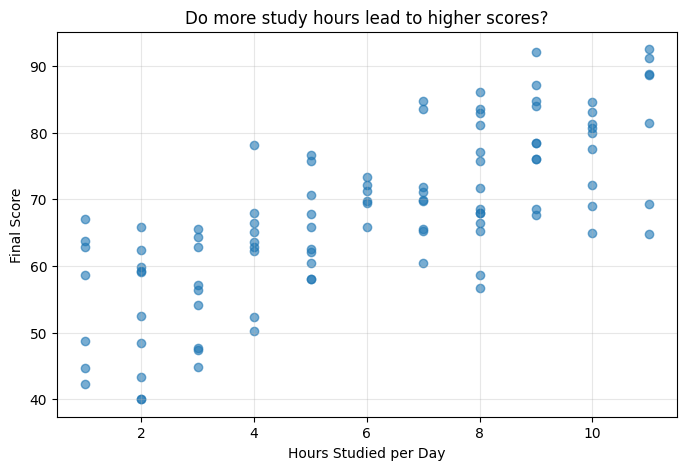


💡 What we see:
   - Students who study more tend to score higher
   - But it's not perfect (other factors matter too)
   - This is where our ML model will help!


In [ ]:
# Look at a few students
print("Sample of students:")
print("-"*50)
print(df[['hours_studied', 'final_score']].head(10))

# Calculate average score for different study hours
print("\n📊 Average scores by study hours:")
print("-"*50)

# Group by hours studied and calculate average
avg_by_hours = df.groupby('hours_studied')['final_score'].mean().round(1)
print(avg_by_hours)

# Make a simple plot
plt.figure(figsize=(8, 5))
plt.scatter(df['hours_studied'], df['final_score'], alpha=0.6)
plt.xlabel('Hours Studied per Day')
plt.ylabel('Final Score')
plt.title('Do more study hours lead to higher scores?')
plt.grid(True, alpha=0.3)
plt.show()

print("\n💡 What we see:")
print("   - Students who study more tend to score higher")
print("   - But it's not perfect (other factors matter too)")
print("   - This is where our ML model will help!")

In [ ]:
# Select our feature (what we know) and target (what we want to predict)
feature = ['hours_studied']  # We'll use study hours to predict
target = 'final_score'        # What we want to predict

X = df[feature]  # Features (input)
y = df[target]   # Target (output)

print("✅ Features (what we know):")
print(X.head())
print("\n✅ Target (what we want to predict):")
print(y.head())

print(f"\n📊 We have {len(X)} students")
print(f"   Each student has {len(feature)} feature: study hours")

✅ Features (what we know):
   hours_studied
0              7
1              4
2             11
3              8
4              5

✅ Target (what we want to predict):
0    83.5
1    66.4
2    92.5
3    77.1
4    65.8
Name: final_score, dtype: float64

📊 We have 100 students
   Each student has 1 feature: study hours


In [ ]:
# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"📊 Data Split:")
print(f"   Training set: {len(X_train)} students (80%)")
print(f"   Testing set: {len(X_test)} students (20%)")

print(f"\n📚 Training students (first 5):")
print(X_train.head())

print(f"\n🎯 Their scores (first 5):")
print(y_train.head())

📊 Data Split:
   Training set: 80 students (80%)
   Testing set: 20 students (20%)

📚 Training students (first 5):
    hours_studied
55              3
88              1
26              6
42              7
69              2

🎯 Their scores (first 5):
55    64.4
88    48.8
26    72.1
42    71.9
69    40.0
Name: final_score, dtype: float64


In [ ]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("✅ Model training complete!")
print("\n📐 The model found this formula:")

# Get the numbers the model learned
intercept = model.intercept_
coefficient = model.coef_[0]

print(f"   Predicted Score = {coefficient:.2f} × (Study Hours) + {intercept:.2f}")
print(f"\n💡 This means:")
print(f"   - Base score (0 study hours): {intercept:.1f} points")
print(f"   - Each study hour adds: {coefficient:.2f} points")
print(f"   - If a student studies 5 hours: {5 * coefficient + intercept:.1f} points")
print(f"   - If a student studies 10 hours: {10 * coefficient + intercept:.1f} points")

✅ Model training complete!

📐 The model found this formula:
   Predicted Score = 3.04 × (Study Hours) + 49.81

💡 This means:
   - Base score (0 study hours): 49.8 points
   - Each study hour adds: 3.04 points
   - If a student studies 5 hours: 65.0 points
   - If a student studies 10 hours: 80.2 points


In [ ]:
# Make predictions on test data
predictions = model.predict(X_test)

# Create a simple table to compare
results = pd.DataFrame({
    'Actual Score': y_test.values,
    'Predicted Score': predictions.round(1),
    'Difference': abs(y_test.values - predictions).round(1)
})

print("📊 Comparing Predictions vs Actual:")
print("-"*50)
print(results.head(10))
print("-"*50)

# Calculate average error
avg_error = results['Difference'].mean()
print(f"\n📊 Average prediction error: {avg_error:.1f} points")
print(f"   (This means on average, we're off by {avg_error:.1f} points)")

📊 Comparing Predictions vs Actual:
--------------------------------------------------
   Actual Score  Predicted Score  Difference
0          44.7             52.9         8.2
1          69.9             71.1         1.2
2          81.3             80.2         1.1
3          67.6             77.2         9.6
4          62.2             62.0         0.2
5          65.5             71.1         5.6
6          48.4             55.9         7.5
7          80.0             80.2         0.2
8          81.5             83.3         1.8
9          83.5             71.1        12.4
--------------------------------------------------

📊 Average prediction error: 5.1 points
   (This means on average, we're off by 5.1 points)


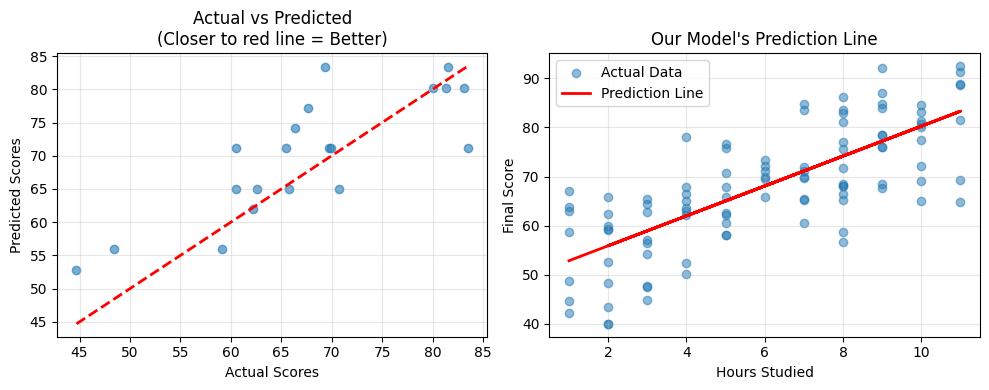

💡 What these graphs show:
   Left: Points close to red line = good predictions
   Right: The red line is our model - it predicts scores based on study hours


In [ ]:
# Create a plot to see how well our model predicts
plt.figure(figsize=(10, 4))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test, predictions, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.title('Actual vs Predicted\n(Closer to red line = Better)')
plt.grid(True, alpha=0.3)

# Plot 2: The regression line
plt.subplot(1, 2, 2)
plt.scatter(X, y, alpha=0.5, label='Actual Data')
plt.plot(X_test, predictions, 'r-', linewidth=2, label='Prediction Line')
plt.xlabel('Hours Studied')
plt.ylabel('Final Score')
plt.title('Our Model\'s Prediction Line')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 What these graphs show:")
print("   Left: Points close to red line = good predictions")
print("   Right: The red line is our model - it predicts scores based on study hours")

In [ ]:
# Calculate simple metrics to understand model quality

# 1. Mean Absolute Error (MAE) - Average error in points
mae = mean_absolute_error(y_test, predictions)

# 2. R-squared - How much variance we explain (0 to 1, higher is better)
r2 = r2_score(y_test, predictions)

print("📊 Model Performance Report:")
print("="*40)
print(f"✓ Mean Absolute Error (MAE): {mae:.1f} points")
print(f"  → On average, our prediction is off by {mae:.1f} points")

print(f"\n✓ R-squared (R²): {r2:.3f}")
print(f"  → Our model explains {r2*100:.1f}% of why students get different scores")

# Simple interpretation
if r2 > 0.7:
    print("\n🎉 Great! The model is working very well!")
elif r2 > 0.5:
    print("\n👍 Good! The model captures the main pattern")
else:
    print("\n📝 The model is simple but gives us a basic understanding")

📊 Model Performance Report:
✓ Mean Absolute Error (MAE): 5.1 points
  → On average, our prediction is off by 5.1 points

✓ R-squared (R²): 0.608
  → Our model explains 60.8% of why students get different scores

👍 Good! The model captures the main pattern


In [ ]:
# Exercise 3: Use multiple features

# Instead of just 'hours_studied', use both 'hours_studied' and 'attendance'
# Let's see if this improves predictions

# Select multiple features
features_multiple = ['hours_studied', 'attendance']
X_multi = df[features_multiple]
y_multi = df['final_score']

# Split data
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

# Train new model
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

# Make predictions
predictions_multi = model_multi.predict(X_test_m)

# Calculate R²
r2_multi = r2_score(y_test_m, predictions_multi)

print(f"R² with only study hours: {r2:.3f}")
print(f"R² with study hours + attendance: {r2_multi:.3f}")
print(f"\n📈 Improvement: {(r2_multi - r2)100:.1f}% better!") *

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2846480893.py, line 26)